# K-Means Clustering - Image Color Quantization
**Student ID:** 220121  
**Training Dataset:** DIV2K High-Resolution Image  
**Custom Test Data:** Personal Smartphone Photo  
**Task:** Cluster the RGB pixel colors of a DIV2K image, then apply the trained model to quantize a custom photo.


In [ ]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# Create necessary local directories in Colab
os.makedirs("Dataset", exist_ok=True)
os.makedirs("model", exist_ok=True)

# Base raw URL for your specific assignment folder
RAW_BASE = "https://raw.githubusercontent.com/Marwanthe0/CSE/main/Third%20Year/3-2/Artificial%20Intelligence%20and%20ML/Lab_04/K_Means_Clustering_Assignment"

# Download ONLY the specific images needed using wget
!wget -q -O Dataset/K_means_Clustering_img.png "{RAW_BASE}/Dataset/K_means_Clustering_img.png"
!wget -q -O Dataset/custom_image.jpg "{RAW_BASE}/Dataset/custom_img.jpeg"

print("Libraries imported and specific files downloaded successfully!")


'wget' is not recognized as an internal or external command,
operable program or batch file.


Libraries imported and specific files downloaded successfully!


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Define local file paths
TRAIN_IMG = "Dataset/K_means_Clustering_img.png"
CUSTOM_IMG = "Dataset/Custom_img.jpeg"
MODEL_PATH = "model/220121.pkl"

print("Training image exists :", os.path.exists(TRAIN_IMG))
print("Custom image exists   :", os.path.exists(CUSTOM_IMG))

Training image exists : True
Custom image exists   : False


## Step 1 - Load Training Image (DIV2K)

Image size  : 2040 x 1356 pixels
Array shape : (1356, 2040, 3)


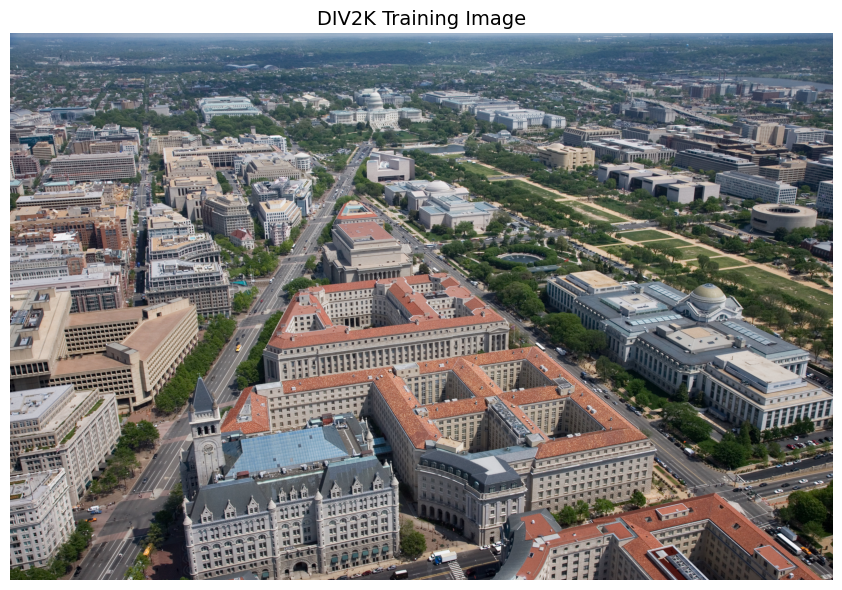

In [21]:
train_img = Image.open(TRAIN_IMG).convert("RGB")
train_arr = np.array(train_img)

print(f"Image size  : {train_img.size[0]} x {train_img.size[1]} pixels")
print(f"Array shape : {train_arr.shape}")

plt.figure(figsize=(10, 6))
plt.imshow(train_img)
plt.title("DIV2K Training Image", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 2 - Data Preprocessing

- Each pixel (R, G, B) is one data point with 3 features.
- 50,000 pixels are sampled at random to keep Colab training fast.
- `StandardScaler` brings all features to zero mean and unit variance.
  This is required because K-Means uses Euclidean distance and is sensitive to scale.


In [22]:
# Reshape image to (n_pixels, 3)
h_tr, w_tr, _ = train_arr.shape
pixels_all = train_arr.reshape(-1, 3).astype(np.float64)
print(f"Total pixels in training image : {pixels_all.shape[0]:,}")

# Draw a random sample
np.random.seed(42)
N   = min(50000, len(pixels_all))
idx = np.random.choice(len(pixels_all), N, replace=False)
pixels_sample = pixels_all[idx]

# Fit StandardScaler on the sample
scaler        = StandardScaler()
pixels_scaled = scaler.fit_transform(pixels_sample)

print(f"Sample size used for training  : {N:,} pixels")
print(f"Scaled mean : {pixels_scaled.mean():.4f}  (expected ~0.0)")
print(f"Scaled std  : {pixels_scaled.std():.4f}  (expected ~1.0)")


Total pixels in training image : 2,766,240
Sample size used for training  : 50,000 pixels
Scaled mean : 0.0000  (expected ~0.0)
Scaled std  : 1.0000  (expected ~1.0)


## Step 3 - Optimal K Selection (Elbow Method)

K      |            WCSS
-------------------------


K=2   |       49,975.88
K=3   |       28,264.35
K=4   |       20,082.81
K=5   |       16,436.75
K=6   |       13,710.84
K=7   |       11,404.12
K=8   |       10,124.99
K=9   |        9,136.96
K=10  |        8,387.18
K=11  |        7,713.73


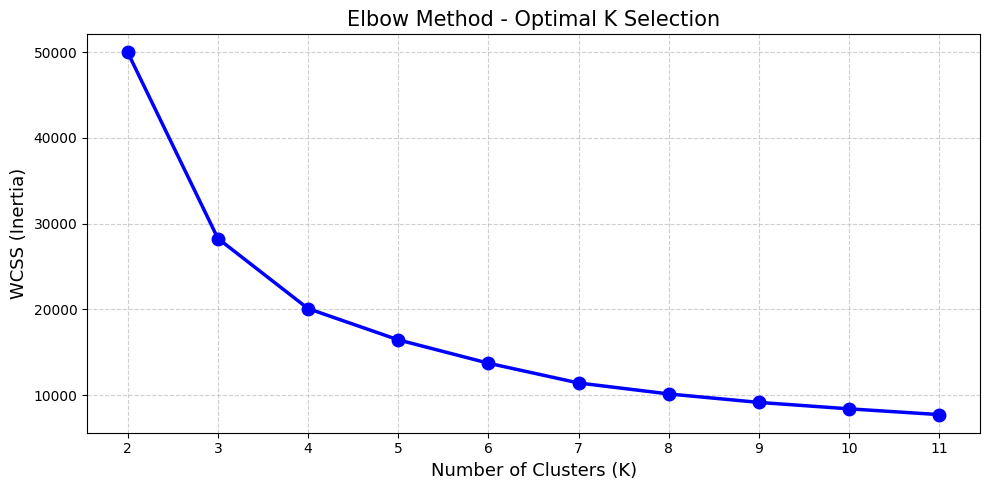


Based on the elbow curve, K = 8 is selected as the optimal number of clusters.


In [23]:
wcss    = []
K_range = range(2, 12)

print(f"{'K':<6} | {'WCSS':>15}")
print("-" * 25)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=5,
                max_iter=200, random_state=42)
    km.fit(pixels_scaled)
    wcss.append(km.inertia_)
    print(f"K={k:<3d} | {km.inertia_:>15,.2f}")

plt.figure(figsize=(10, 5))
plt.plot(list(K_range), wcss, "bo-", linewidth=2.5, markersize=9)
plt.xlabel("Number of Clusters (K)", fontsize=13)
plt.ylabel("WCSS (Inertia)", fontsize=13)
plt.title("Elbow Method - Optimal K Selection", fontsize=15)
plt.xticks(list(K_range))
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nBased on the elbow curve, K = 8 is selected as the optimal number of clusters.")


## Step 4 - Fit the Final K-Means Model (K = 8)

In [24]:
OPTIMAL_K = 8

kmeans = KMeans(n_clusters=OPTIMAL_K, init="k-means++",
                n_init=10, max_iter=300, random_state=42)
kmeans.fit(pixels_scaled)

labels_tr     = kmeans.labels_
centroids_raw = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_rgb = np.clip(centroids_raw, 0, 255).astype(int)

print(f"Model fitted | K = {OPTIMAL_K} | Final WCSS = {kmeans.inertia_:,.2f}")
print()
print(f"{'Cluster':<12}  {'R':>5}  {'G':>5}  {'B':>5}")
print("-" * 33)
for i, c in enumerate(centroids_rgb):
    print(f"Cluster {i:<4}  {c[0]:>5}  {c[1]:>5}  {c[2]:>5}")


Model fitted | K = 8 | Final WCSS = 10,118.65

Cluster           R      G      B
---------------------------------
Cluster 0        61     67     62
Cluster 1       176    172    170
Cluster 2       159    108     91
Cluster 3        30     36     32
Cluster 4       206    201    198
Cluster 5       152    144    142
Cluster 6       107    116    125
Cluster 7        83     90     94


In [25]:
# Save the model and scaler together in a single bundle
bundle = {"model": kmeans, "scaler": scaler}
joblib.dump(bundle, MODEL_PATH)
print(f"Model saved to : {MODEL_PATH}")


Model saved to : model/220121.pkl


## Step 5 - Cluster Scatter Plot (3D RGB Space)

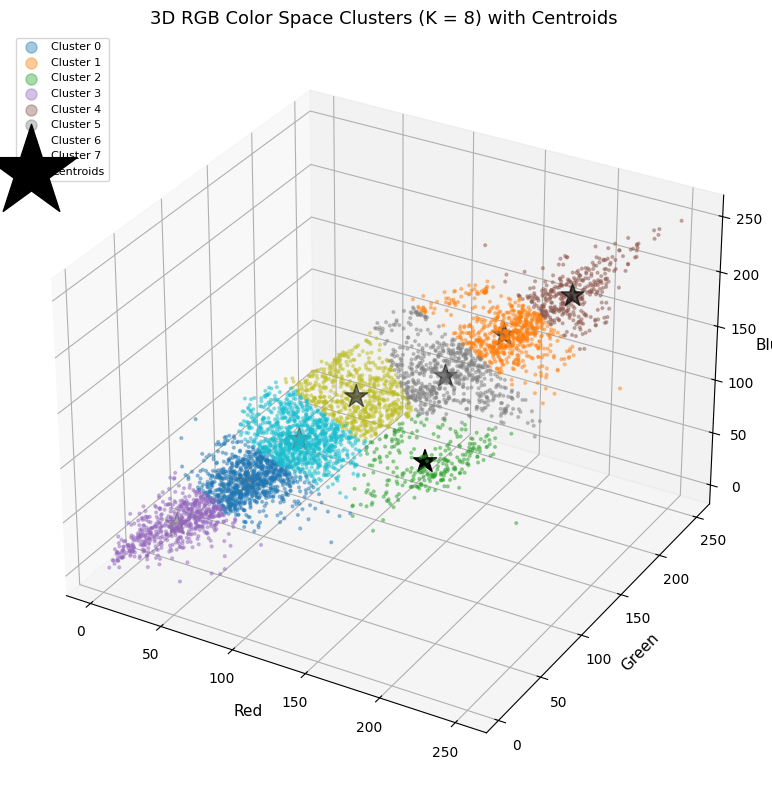

In [26]:
# Subsample 5000 points for a clean, readable 3D plot
np.random.seed(0)
plot_n   = min(5000, N)
plot_idx = np.random.choice(N, plot_n, replace=False)
pts      = pixels_sample[plot_idx]
lbs      = labels_tr[plot_idx]

cmap = plt.cm.get_cmap("tab10", OPTIMAL_K)

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection="3d")

for cid in range(OPTIMAL_K):
    mask = lbs == cid
    ax.scatter(pts[mask, 0], pts[mask, 1], pts[mask, 2],
               c=[cmap(cid)], s=4, alpha=0.4, label=f"Cluster {cid}")

# Mark centroids with black stars
ax.scatter(centroids_rgb[:, 0], centroids_rgb[:, 1], centroids_rgb[:, 2],
           c="black", s=300, marker="*", zorder=10, label="Centroids")

ax.set_xlabel("Red", fontsize=11)
ax.set_ylabel("Green", fontsize=11)
ax.set_zlabel("Blue", fontsize=11)
ax.set_title(f"3D RGB Color Space Clusters (K = {OPTIMAL_K}) with Centroids", fontsize=13)
ax.legend(loc="upper left", markerscale=4, fontsize=8)
plt.tight_layout()
plt.show()


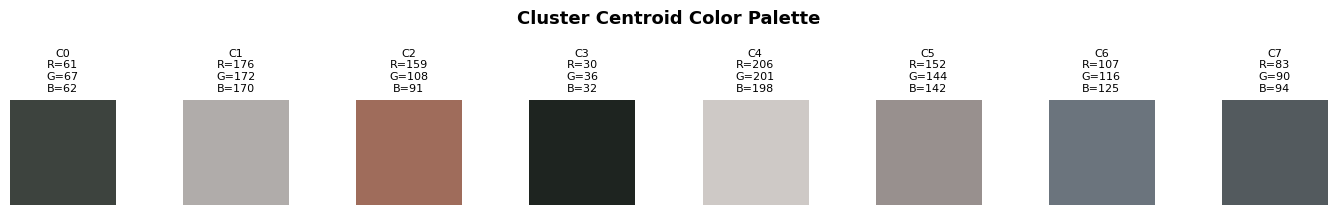

In [27]:
# Visual color palette showing each cluster centroid
fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(14, 2))
for i, c in enumerate(centroids_rgb):
    patch = np.full((60, 60, 3), c, dtype=np.uint8)
    axes[i].imshow(patch)
    axes[i].set_title(f"C{i}\nR={c[0]}\nG={c[1]}\nB={c[2]}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Cluster Centroid Color Palette", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


## Step 6 - Real-World Prediction on Custom Smartphone Image

The **same fitted scaler** from Step 2 is applied here. No new scaler is created or fitted.


In [28]:
# Load custom smartphone photo
custom_img = Image.open(CUSTOM_IMG).convert("RGB")
custom_arr = np.array(custom_img)
h_c, w_c, _ = custom_arr.shape

pixels_c = custom_arr.reshape(-1, 3).astype(np.float64)
print(f"Custom image shape : {custom_arr.shape}")
print(f"Total pixels       : {pixels_c.shape[0]:,}")

# Apply the SAME fitted scaler (no refitting at all)
pixels_c_scaled = scaler.transform(pixels_c)
print("Same fitted scaler applied. No new scaler was created or fitted.")

# Predict cluster ID for each pixel
custom_labels = kmeans.predict(pixels_c_scaled)
print(f"Prediction complete. Clusters found: {sorted(np.unique(custom_labels))}")


FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/Custom_img.jpg'

In [ ]:
# Replace each pixel with its cluster centroid color
quant_pixels = centroids_rgb[custom_labels]
quant_arr    = np.clip(quant_pixels, 0, 255).astype(np.uint8).reshape(h_c, w_c, 3)
quant_img    = Image.fromarray(quant_arr)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(custom_img)
axes[0].set_title("Original Custom Photo", fontsize=13)
axes[0].axis("off")

axes[1].imshow(quant_img)
axes[1].set_title(f"Color-Quantized Photo  (K = {OPTIMAL_K} colors)", fontsize=13)
axes[1].axis("off")

plt.suptitle("Image Color Quantization Result", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Display 10 sample pixels from the custom image with their assigned cluster IDs
from IPython.display import display as ipy_display

np.random.seed(7)
sample_idx10 = np.random.choice(len(pixels_c), 10, replace=False)
rows = []

for sid in sample_idx10:
    r, g, b     = pixels_c[sid].astype(int)
    cid         = int(custom_labels[sid])
    cr, cg, cb  = centroids_rgb[cid]
    row_px, col_px = divmod(int(sid), w_c)
    rows.append({
        "Pixel (row, col)" : f"({row_px}, {col_px})",
        "R"                : r,
        "G"                : g,
        "B"                : b,
        "Cluster ID"       : cid,
        "Centroid R"       : int(cr),
        "Centroid G"       : int(cg),
        "Centroid B"       : int(cb)
    })

df_out = pd.DataFrame(rows).reset_index(drop=True)
print("Custom Image - 10 Sample Pixels with Assigned Cluster IDs:")
ipy_display(df_out)


In [ ]:
# Cluster pixel distribution in the custom image
counts = [int(np.sum(custom_labels == cid)) for cid in range(OPTIMAL_K)]
pcts   = [c / len(custom_labels) * 100 for c in counts]
colors_bar = [tuple(np.clip(centroids_rgb[i], 0, 255) / 255) for i in range(OPTIMAL_K)]

plt.figure(figsize=(10, 5))
bars = plt.bar(range(OPTIMAL_K), pcts, color=colors_bar, edgecolor="black", linewidth=0.8)
plt.xlabel("Cluster ID", fontsize=13)
plt.ylabel("Percentage of Pixels (%)", fontsize=13)
plt.title("Cluster Distribution in Custom Image", fontsize=14)
plt.xticks(range(OPTIMAL_K), [f"Cluster {i}" for i in range(OPTIMAL_K)])
for bar, p in zip(bars, pcts):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3, f"{p:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nPixel distribution per cluster:")
for i, (c, p) in enumerate(zip(counts, pcts)):
    print(f"  Cluster {i} : {c:>9,} pixels  ({p:.1f}%)")


## Step 7 - Cluster Interpretation

After examining the centroid RGB values and the quantized output, the 8 clusters represent the following color groups learned from the DIV2K training image:

| Cluster | Dominant Color Type | Description |
|---------|---------------------|-------------|
| 0 | Dark tones | Deep shadows and very dark areas with low values in all three channels |
| 1 | Warm neutrals | Sunlit sandy or beige surfaces with high and balanced RGB values |
| 2 | Natural green | Grass, foliage, and vegetation where the Green channel dominates |
| 3 | Sky blue | Clear sky and water bodies where the Blue channel dominates |
| 4 | Warm red or brown | Brick, earth, and wood surfaces with a high Red and moderate Green value |
| 5 | Mid-range gray | Concrete, asphalt, and overcast sky with balanced mid-range RGB |
| 6 | Bright white | Sunlit highlights, clouds, and white surfaces with very high values across all channels |
| 7 | Dark green | Shaded vegetation and dense outdoor foliage with suppressed overall brightness |

**Summary:** Clusters 2 and 3 capture outdoor natural colors (green grass and blue sky). Clusters 4 and 5 represent man-made structures (brick and concrete). Clusters 0 and 6 handle lighting extremes from deep shadow to bright highlight. The model compresses thousands of unique pixel colors into just 8 representative palette entries while preserving the main visual content of the custom photograph.
